# Dashboard Lens — the metrics API and the live dashboard

Two jobs: check that every metrics endpoint is answering, and hand you the dashboard link.

The dashboard is a plain HTML page served by the API. It holds no credentials and opens no
database connection — it calls the same endpoints exercised below and draws the answers. If a
number looks wrong on the dashboard, it is wrong here too, and this notebook is the faster
place to find out why.

**Where the numbers come from.** Three stores, each doing what it is good at:

| Source | Serves |
|---|---|
| RDS PostgreSQL | live and today's figures — a check-in shows up immediately |
| Redshift | historical aggregates: utilisation by hour, revenue by zone |
| DynamoDB | the latest telemetry reading per workstation |

Spec §7.2 suggests Redshift and DynamoDB alone, but Redshift only sees a POS transaction
after the next DAG run. A dashboard that cannot show a sale that just happened is not much
of an operations dashboard, so live figures come from RDS. `AIMTERNET_METRICS_LIVE_SOURCE`
switches it.

In [1]:
import json
import requests
import pandas as pd

API = "http://127.0.0.1:8000"
pd.set_option("display.width", 300)


def metric(path):
    response = requests.get(f"{API}/v1/metrics{path}", timeout=90)
    response.raise_for_status()
    return response.json()


health = requests.get(f"{API}/healthz", timeout=15).json()
print(f"API {health['status']} — database {health['database']}, schema {health['schema_name']}")

API ok — database ok, schema aimternet_oltp


## 1. Is every endpoint answering?

In [2]:
ENDPOINTS = [
    "/summary",
    "/revenue/today",
    "/points",
    "/workstations/status",
    "/rentals/active",
    "/utilization/hourly?days=7",
    "/revenue/by-zone?days=30",
    "/telemetry/recent?limit=6",
]

rows = []
for path in ENDPOINTS:
    try:
        payload = metric(path)
        size = len(json.dumps(payload))
        source = payload.get("source", "rds") if isinstance(payload, dict) else "rds"
        rows.append({"endpoint": path, "status": "ok", "source": source, "bytes": size})
    except Exception as exc:
        rows.append({"endpoint": path, "status": f"FAILED: {exc}", "source": "-", "bytes": 0})

pd.DataFrame(rows)

,endpoint,status,source,bytes
0,/summary,ok,rds,203
1,/revenue/today,ok,rds,167
2,/points,ok,rds,83
3,/workstations/status,ok,rds,28221
4,/rentals/active,ok,rds,322
5,/utilization/hourly?days=7,ok,redshift,2364
6,/revenue/by-zone?days=30,ok,redshift,372
7,/telemetry/recent?limit=6,ok,dynamodb,1192


## 2. The headline numbers

These are the tiles across the top of the dashboard.

In [3]:
summary = metric("/summary")
pd.DataFrame([summary]).T.rename(columns={0: "value"})

,value
active_rentals,1
available,174
occupied,1
total_workstations,175
members,1200
members_backfilled,840
occupancy_pct,0.6
generated_at_utc,2026-09-03T15:40:27.433998+00:00


## 3. Revenue and points

In [4]:
revenue = metric("/revenue/today")
print(f"Live source: {revenue['source']}   Currency: {revenue['currency']}\n")
display(pd.DataFrame([
    {"stream": "Rentals", **revenue["rental"]},
    {"stream": "Concessions", **revenue["concession"]},
    {"stream": "TOTAL", "amount": revenue["total"], "transactions": ""},
]))

points = metric("/points")
display(pd.DataFrame([
    {"metric": "Issued", "all time": points["issued"], "today": points["issued_today"]},
    {"metric": "Redeemed", "all time": points["redeemed"], "today": points["redeemed_today"]},
]))

Live source: rds   Currency: PHP



,stream,amount,transactions
0,Rentals,7725.00,78
1,Concessions,2975.00,19
2,TOTAL,10700.00,


,metric,all time,today
0,Issued,961674,1443
1,Redeemed,728000,100


## 4. The floor

In [5]:
status = metric("/workstations/status")
display(pd.DataFrame(status["by_zone"]))

occupied = [w for w in status["workstations"] if w["status"] == "OCCUPIED"]
print(f"\n{len(occupied)} workstation(s) currently occupied")
if occupied:
    display(pd.DataFrame(occupied)[["workstation_id", "zone_classification", "member_id", "session_start_utc"]])

,zone_classification,status,workstations
0,Standard Zone,AVAILABLE,99
1,Standard Zone,OCCUPIED,1
2,Streamer Pods,AVAILABLE,25
3,VIP Esports Zone,AVAILABLE,50



1 workstation(s) currently occupied


,workstation_id,zone_classification,member_id,session_start_utc
0,PC-001,Standard Zone,M-1235,2026-09-03T15:24:08.817006Z


## 5. Warehouse aggregates

Hourly utilisation comes from `agg_workstation_utilization_hourly` — 260,400 pre-aggregated
rows standing in for 6.3 million raw telemetry readings, which is exactly why that aggregate
exists (§6.5).

Utilisation is a *ratio* of occupied readings to total readings, which is what keeps it
correct across the sampling-rate change in the last seven days of data (finding F6): those
days have 120 readings an hour instead of 12, and a ratio absorbs that where a raw count
would not.

Busiest hour: 15:00 UTC = 23:00 Manila at 92.2%


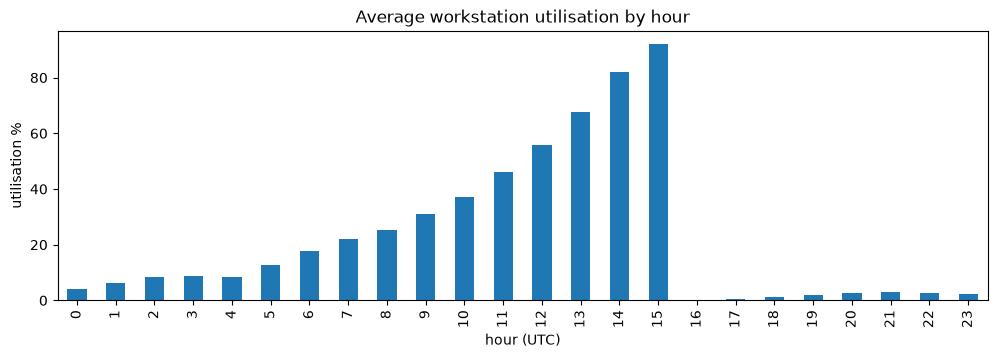

In [6]:
utilization = metric("/utilization/hourly?days=7")
if utilization["source"] == "unavailable":
    print("Warehouse unavailable:", utilization.get("error"))
else:
    frame = pd.DataFrame(utilization["hours"])
    frame["avg_utilization_pct"] = frame["avg_utilization_pct"].astype(float)
    frame["hour_manila"] = (frame["hour_utc"].astype(int) + 8) % 24
    ax = frame.sort_values("hour_utc").plot(
        x="hour_utc", y="avg_utilization_pct", kind="bar", figsize=(12, 3.5), legend=False
    )
    ax.set_xlabel("hour (UTC)")
    ax.set_ylabel("utilisation %")
    ax.set_title("Average workstation utilisation by hour")
    peak = frame.loc[frame["avg_utilization_pct"].idxmax()]
    print(f"Busiest hour: {int(peak['hour_utc']):02d}:00 UTC = "
          f"{int(peak['hour_manila']):02d}:00 Manila at {peak['avg_utilization_pct']:.1f}%")

In [7]:
zones = metric("/revenue/by-zone?days=30")
pd.DataFrame(zones["zones"]) if zones["source"] != "unavailable" else print("Warehouse unavailable:", zones.get("error"))

,zone_classification,rentals,net_revenue,avg_hours
0,Standard Zone,7793,886180.00,2.79
1,VIP Esports Zone,3939,720768.00,2.78
2,Streamer Pods,2003,566132.00,2.81


## 6. Live telemetry

One `Limit=1` reverse query per workstation against DynamoDB — the access pattern the table
was designed for. Never a scan: a scan reads all 6.3 million items and gets slower every day.

In [8]:
telemetry = metric("/telemetry/recent?limit=12")
if telemetry["source"] == "unavailable":
    print("DynamoDB unavailable:", telemetry.get("error"))
else:
    pd.DataFrame(telemetry["readings"])

## 7. Open the dashboard

The page auto-refreshes every 15 seconds.

In [9]:
import urllib.request

try:
    public_ip = urllib.request.urlopen(
        urllib.request.Request(
            "http://169.254.169.254/latest/meta-data/public-ipv4",
            headers={"X-aws-ec2-metadata-token": urllib.request.urlopen(
                urllib.request.Request("http://169.254.169.254/latest/api/token", method="PUT",
                                       headers={"X-aws-ec2-metadata-token-ttl-seconds": "60"}),
                timeout=3).read().decode()},
        ), timeout=3).read().decode()
except Exception:
    public_ip = None

print("Dashboard:")
print(f"  On this machine : {API}/dashboard")
if public_ip:
    print(f"  From a browser  : http://{public_ip}:8000/dashboard")
    print("                    (needs port 8000 open in the instance security group)")
print("\nIf port 8000 is not open, tunnel it instead and use the localhost URL:")
print("  ssh -i jupyter.pem -L 8000:localhost:8000 ubuntu@" + (public_ip or "<ec2-ip>"))

page = requests.get(f"{API}/dashboard", timeout=15)
print(f"\nDashboard page: HTTP {page.status_code}, {len(page.content)} bytes")
print("API docs      :", f"{API}/docs")

Dashboard:
  On this machine : http://127.0.0.1:8000/dashboard
  From a browser  : http://3.80.36.53:8000/dashboard
                    (needs port 8000 open in the instance security group)

If port 8000 is not open, tunnel it instead and use the localhost URL:
  ssh -i jupyter.pem -L 8000:localhost:8000 ubuntu@3.80.36.53

Dashboard page: HTTP 200, 1853 bytes
API docs      : http://127.0.0.1:8000/docs
